<a href="https://colab.research.google.com/github/tkottai-hoshin/ml-diabetes-risk-prediction-nhanes/blob/main/NHANES_diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost lightgbm shap -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [1]:
import os
os.listdir('/content')

['.config',
 'P_BMX.xpt',
 'P_GLU.xpt',
 'P_DEMO.xpt',
 'P_INS.xpt',
 'P_GHB.xpt',
 'P_BPXO.xpt',
 'P_TCHOL.xpt',
 'sample_data']

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

MessageError: Error: credential propagation was unsuccessful

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
import os
os.listdir('/content')

['.config', 'drive', 'sample_data']

In [6]:
os.listdir('/content')

['.config', 'drive', 'sample_data']

In [8]:
os.listdir('/content')

['.config', 'P_DEMO.xpt', 'drive', 'sample_data']

In [9]:
import pandas as pd

# Load the .xpt file
df = pd.read_sas('/content/P_DEMO.xpt')

# Check basic info
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

df.head()

Shape: (15560, 29)

Column names:
['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMDBORN4', 'DMDYRUSZ', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'WTINTPRP', 'WTMECPRP', 'SDMVPSU', 'SDMVSTRA', 'INDFMPIR']


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,...,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,WTINTPRP,WTMECPRP,SDMVPSU,SDMVSTRA,INDFMPIR
0,109263.0,66.0,2.0,1.0,2.0,NaN,5.0,6.0,2.0,1.0,...,2.0,NaN,NaN,NaN,NaN,7891.762435,8.951816e+03,3.0,156.0,4.66
1,109264.0,66.0,2.0,2.0,13.0,NaN,1.0,1.0,2.0,1.0,...,2.0,1.0,2.0,2.0,1.0,11689.747264,1.227116e+04,1.0,155.0,0.83
2,109265.0,66.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,1.0,...,2.0,NaN,NaN,NaN,NaN,16273.825939,1.665876e+04,1.0,157.0,3.06
3,109266.0,66.0,2.0,2.0,29.0,NaN,5.0,6.0,2.0,2.0,...,2.0,1.0,2.0,2.0,1.0,7825.646112,8.154968e+03,2.0,168.0,5.00
4,109267.0,66.0,1.0,2.0,21.0,NaN,2.0,2.0,NaN,2.0,...,2.0,NaN,NaN,NaN,NaN,26379.991724,5.397605e-79,1.0,156.0,5.00


In [7]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'diabetes-risk-prediction',
 'College Essays',
 'College Info',
 'ECE 265',
 'High School  Old stuff',
 'Junk',
 'Untitled document (6).gdoc',
 'Tariq 2014.gdoc',
 'Experiement 5 ECE.doc',
 'Experiement 5 ECE.doc.gdoc',
 'ECE 225.zip',
 'FilterFresh.gdoc',
 'TotalLoop letter.gdoc',
 'LBS Letter.gdoc',
 'Resume - 2015 - August.gdoc',
 'PwC Resume - 2015 - August.gdoc',
 'Taylor Series.gdoc',
 'TotalLoop message.gdoc',
 'Sales Sheet.gsheet',
 'Sedra Microelectronic Circuits 6th c2010 txtbk.pdf',
 'ExamQuestionsUP.pdf',
 'Test3-073015.pdf',
 'Tariq_Kottai_Resume (1).pdf',
 'Resume-most recent.docx',
 'IMG_0342.PNG',
 'IMG_0337.JPG',
 'IMG_0336.JPG',
 'IMG_0334.JPG',
 'IMG_0335.JPG',
 'ECE350-labs.zip',
 'IPD.gdoc',
 'Future Markets.gdoc',
 'Follow.ino',
 'Problem6_1.m',
 'Problem6_1.m.gdoc',
 'Problem6_2.m',
 'Problem6_2.m.gdoc',
 'Problem6_3.m',
 'Problem6_3.m.gdoc',
 'Problem6_4.m',
 'Problem6_4.m.gdoc',
 '342 Presentation.gslides',
 'Untitled document (5).gdoc',
 '

In [11]:
# Select the most useful columns
useful_cols = [
    'SEQN',          # Unique ID
    'RIAGENDR',      # Gender
    'RIDAGEYR',      # Age in years
    'RIDRETH3',      # Race/Ethnicity
    'DMDEDUC2',      # Education
    'INDFMPIR'       # Income-to-Poverty ratio
]

df_clean = df[useful_cols].copy()

# Rename columns to make them readable
df_clean = df_clean.rename(columns={
    'SEQN': 'id',
    'RIAGENDR': 'gender',
    'RIDAGEYR': 'age',
    'RIDRETH3': 'race',
    'DMDEDUC2': 'education',
    'INDFMPIR': 'income_poverty_ratio'
})

# Quick check
print("Cleaned shape:", df_clean.shape)
print("\nMissing values:")
print(df_clean.isnull().sum())

df_clean.head(10)

Cleaned shape: (15560, 6)

Missing values:
id                         0
gender                     0
age                        0
race                       0
education               6328
income_poverty_ratio    2201
dtype: int64


,id,gender,age,race,education,income_poverty_ratio
0,109263.0,1.0,2.000000e+00,6.0,NaN,4.66
1,109264.0,2.0,1.300000e+01,1.0,NaN,0.83
2,109265.0,1.0,2.000000e+00,3.0,NaN,3.06
3,109266.0,2.0,2.900000e+01,6.0,5.0,5.00
4,109267.0,2.0,2.100000e+01,2.0,4.0,5.00
5,109268.0,2.0,1.800000e+01,3.0,NaN,1.66
6,109269.0,1.0,2.000000e+00,2.0,NaN,0.96
7,109270.0,2.0,1.100000e+01,4.0,NaN,1.88
8,109271.0,1.0,4.900000e+01,3.0,2.0,NaN
9,109272.0,1.0,5.397605e-79,1.0,NaN,0.73


In [12]:
# 1. Create readable labels
df_clean['gender'] = df_clean['gender'].map({1: 'Male', 2: 'Female'})

df_clean['race'] = df_clean['race'].map({
    1: 'Mexican American',
    2: 'Other Hispanic',
    3: 'Non-Hispanic White',
    4: 'Non-Hispanic Black',
    6: 'Non-Hispanic Asian',
    7: 'Other Race'
})

df_clean['education'] = df_clean['education'].map({
    1: 'Less than 9th grade',
    2: '9-11th grade',
    3: 'High school graduate',
    4: 'Some college',
    5: 'College graduate'
})

# 2. Fix age (turn tiny numbers into 0)
df_clean['age'] = df_clean['age'].apply(lambda x: 0 if x < 1 else x)

# 3. Check the cleaned data
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nFirst 10 rows:")
df_clean.head(10)

Missing values after cleaning:
id                         0
gender                     0
age                        0
race                       0
education               6343
income_poverty_ratio    2201
dtype: int64

First 10 rows:


,id,gender,age,race,education,income_poverty_ratio
0,109263.0,Male,2.0,Non-Hispanic Asian,NaN,4.66
1,109264.0,Female,13.0,Mexican American,NaN,0.83
2,109265.0,Male,2.0,Non-Hispanic White,NaN,3.06
3,109266.0,Female,29.0,Non-Hispanic Asian,College graduate,5.00
4,109267.0,Female,21.0,Other Hispanic,Some college,5.00
5,109268.0,Female,18.0,Non-Hispanic White,NaN,1.66
6,109269.0,Male,2.0,Other Hispanic,NaN,0.96
7,109270.0,Female,11.0,Non-Hispanic Black,NaN,1.88
8,109271.0,Male,49.0,Non-Hispanic White,9-11th grade,NaN
9,109272.0,Male,0.0,Mexican American,NaN,0.73


In [13]:
# 1. Create a simple adult flag (age 20 and older)
df_clean['is_adult'] = df_clean['age'] >= 20

# 2. Fill missing income with the median (common simple approach)
median_income = df_clean['income_poverty_ratio'].median()
df_clean['income_poverty_ratio'] = df_clean['income_poverty_ratio'].fillna(median_income)

# 3. For education: keep NaN for now (or fill with "Not applicable" for children)
df_clean['education'] = df_clean['education'].fillna('Not applicable (under 20)')

# 4. Final check
print("Missing values left:")
print(df_clean.isnull().sum())

print("\nData overview:")
print(df_clean.describe(include='all'))

print("\nFirst 10 rows:")
df_clean.head(10)

Missing values left:
id                      0
gender                  0
age                     0
race                    0
education               0
income_poverty_ratio    0
is_adult                0
dtype: int64

Data overview:
                  id  gender           age                race  \
count    15560.00000   15560  15560.000000               15560   
unique           NaN       2           NaN                   6   
top              NaN  Female           NaN  Non-Hispanic White   
freq             NaN    7839           NaN                5271   
mean    117042.50000     NaN     33.742481                 NaN   
std       4491.92943     NaN     25.320532                 NaN   
min     109263.00000     NaN      0.000000                 NaN   
25%     113152.75000     NaN     10.000000                 NaN   
50%     117042.50000     NaN     30.000000                 NaN   
75%     120932.25000     NaN     56.000000                 NaN   
max     124822.00000     NaN     80.000000

,id,gender,age,race,education,income_poverty_ratio,is_adult
0,109263.0,Male,2.0,Non-Hispanic Asian,Not applicable (under 20),4.66,False
1,109264.0,Female,13.0,Mexican American,Not applicable (under 20),0.83,False
2,109265.0,Male,2.0,Non-Hispanic White,Not applicable (under 20),3.06,False
3,109266.0,Female,29.0,Non-Hispanic Asian,College graduate,5.00,True
4,109267.0,Female,21.0,Other Hispanic,Some college,5.00,True
5,109268.0,Female,18.0,Non-Hispanic White,Not applicable (under 20),1.66,False
6,109269.0,Male,2.0,Other Hispanic,Not applicable (under 20),0.96,False
7,109270.0,Female,11.0,Non-Hispanic Black,Not applicable (under 20),1.88,False
8,109271.0,Male,49.0,Non-Hispanic White,9-11th grade,1.96,True
9,109272.0,Male,0.0,Mexican American,Not applicable (under 20),0.73,False


In [14]:
# Basic overview
print("Total people:", len(df_clean))
print("Number of adults (20+):", df_clean['is_adult'].sum())
print("Number of children/teens:", (~df_clean['is_adult']).sum())

print("\n--- Gender distribution ---")
print(df_clean['gender'].value_counts())

print("\n--- Race distribution ---")
print(df_clean['race'].value_counts())

print("\n--- Education (Adults only) ---")
print(df_clean[df_clean['is_adult']]['education'].value_counts())

print("\n--- Age statistics ---")
print(df_clean['age'].describe())

print("\n--- Income-to-Poverty Ratio statistics ---")
print(df_clean['income_poverty_ratio'].describe())

Total people: 15560
Number of adults (20+): 9232
Number of children/teens: 6328

--- Gender distribution ---
gender
Female    7839
Male      7721
Name: count, dtype: int64

--- Race distribution ---
race
Non-Hispanic White    5271
Non-Hispanic Black    4098
Mexican American      1990
Non-Hispanic Asian    1638
Other Hispanic        1544
Other Race            1019
Name: count, dtype: int64

--- Education (Adults only) ---
education
Some college                 2975
College graduate             2257
High school graduate         2225
9-11th grade                 1041
Less than 9th grade           719
Not applicable (under 20)      15
Name: count, dtype: int64

--- Age statistics ---
count    15560.000000
mean        33.742481
std         25.320532
min          0.000000
25%         10.000000
50%         30.000000
75%         56.000000
max         80.000000
Name: age, dtype: float64

--- Income-to-Poverty Ratio statistics ---
count    1.556000e+04
mean     2.342858e+00
std      1.522295e+00

In [2]:
import pandas as pd

# Load the new files
ghb = pd.read_sas('/content/P_GHB.xpt')      # HbA1c
glu = pd.read_sas('/content/P_GLU.xpt')      # Fasting Glucose
bmx = pd.read_sas('/content/P_BMX.xpt')      # Body Measures
bpx = pd.read_sas('/content/P_BPXO.xpt')     # Blood Pressure
tchol = pd.read_sas('/content/P_TCHOL.xpt')  # Total Cholesterol
ins = pd.read_sas('/content/P_INS.xpt')      # Insulin

# Quick check
print("GHB shape:", ghb.shape)
print("GLU shape:", glu.shape)
print("BMX shape:", bmx.shape)
print("BPX shape:", bpx.shape)
print("TCHOL shape:", tchol.shape)
print("INS shape:", ins.shape)

GHB shape: (10409, 2)
GLU shape: (5090, 4)
BMX shape: (14300, 22)
BPX shape: (11656, 12)
TCHOL shape: (12198, 3)
INS shape: (5090, 5)


In [3]:
# Start with the cleaned demographics we already have
df = df_clean.copy()

# Merge HbA1c (most important for diabetes target)
df = df.merge(ghb, left_on='id', right_on='SEQN', how='left')

# Merge Body Measures
df = df.merge(bmx, left_on='id', right_on='SEQN', how='left')

# Check the result
print("Current shape after merging:", df.shape)
print("\nColumns so far:")
print(df.columns.tolist())

NameError: name 'df_clean' is not defined

In [4]:
# Start with the cleaned demographics we already have
df = df_clean.copy()

# Merge HbA1c (most important for diabetes target)
df = df.merge(ghb, left_on='id', right_on='SEQN', how='left')

# Merge Body Measures
df = df.merge(bmx, left_on='id', right_on='SEQN', how='left')

# Check the result
print("Current shape after merging:", df.shape)
print("\nColumns so far:")
print(df.columns.tolist())

NameError: name 'df_clean' is not defined

In [5]:
import pandas as pd

# 1. Load Demographics again
demo = pd.read_sas('/content/P_DEMO.xpt')

# 2. Select and clean the useful columns
df_clean = demo[['SEQN', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH3', 'DMDEDUC2', 'INDFMPIR']].copy()

df_clean = df_clean.rename(columns={
    'SEQN': 'id',
    'RIAGENDR': 'gender',
    'RIDAGEYR': 'age',
    'RIDRETH3': 'race',
    'DMDEDUC2': 'education',
    'INDFMPIR': 'income_poverty_ratio'
})

# Map the codes
df_clean['gender'] = df_clean['gender'].map({1: 'Male', 2: 'Female'})
df_clean['race'] = df_clean['race'].map({
    1: 'Mexican American',
    2: 'Other Hispanic',
    3: 'Non-Hispanic White',
    4: 'Non-Hispanic Black',
    6: 'Non-Hispanic Asian',
    7: 'Other Race'
})
df_clean['education'] = df_clean['education'].map({
    1: 'Less than 9th grade',
    2: '9-11th grade',
    3: 'High school graduate',
    4: 'Some college',
    5: 'College graduate'
})

df_clean['age'] = df_clean['age'].apply(lambda x: 0 if x < 1 else x)
df_clean['is_adult'] = df_clean['age'] >= 20
df_clean['education'] = df_clean['education'].fillna('Not applicable (under 20)')
df_clean['income_poverty_ratio'] = df_clean['income_poverty_ratio'].fillna(df_clean['income_poverty_ratio'].median())

print("df_clean is ready!")
print(df_clean.shape)
df_clean.head()

df_clean is ready!
(15560, 7)


,id,gender,age,race,education,income_poverty_ratio,is_adult
0,109263.0,Male,2.0,Non-Hispanic Asian,Not applicable (under 20),4.66,False
1,109264.0,Female,13.0,Mexican American,Not applicable (under 20),0.83,False
2,109265.0,Male,2.0,Non-Hispanic White,Not applicable (under 20),3.06,False
3,109266.0,Female,29.0,Non-Hispanic Asian,College graduate,5.00,True
4,109267.0,Female,21.0,Other Hispanic,Some college,5.00,True


In [6]:
# Load the important files again (in case they were lost)
ghb = pd.read_sas('/content/P_GHB.xpt')      # HbA1c
bmx = pd.read_sas('/content/P_BMX.xpt')      # Body Measures

# Start with cleaned demographics
df = df_clean.copy()

# Merge HbA1c
df = df.merge(ghb, left_on='id', right_on='SEQN', how='left')

# Merge Body Measures
df = df.merge(bmx, left_on='id', right_on='SEQN', how='left')

# Drop the extra SEQN columns that came from the merges
df = df.drop(columns=['SEQN_x', 'SEQN_y'], errors='ignore')

print("Shape after merging:", df.shape)
print("\nCurrent columns:")
print(df.columns.tolist())

Shape after merging: (15560, 29)

Current columns:
['id', 'gender', 'age', 'race', 'education', 'income_poverty_ratio', 'is_adult', 'LBXGH', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXRECUM', 'BMIRECUM', 'BMXHEAD', 'BMIHEAD', 'BMXHT', 'BMIHT', 'BMXBMI', 'BMDBMIC', 'BMXLEG', 'BMILEG', 'BMXARML', 'BMIARML', 'BMXARMC', 'BMIARMC', 'BMXWAIST', 'BMIWAIST', 'BMXHIP', 'BMIHIP']


In [7]:
# Keep only the useful columns
df = df[[
    'id', 'gender', 'age', 'race', 'education', 'income_poverty_ratio', 'is_adult',
    'LBXGH', 'BMXBMI', 'BMXWAIST', 'BMXWT', 'BMXHT'
]].copy()

# Rename for clarity
df = df.rename(columns={
    'LBXGH': 'hba1c',
    'BMXBMI': 'bmi',
    'BMXWAIST': 'waist',
    'BMXWT': 'weight',
    'BMXHT': 'height'
})

# Create Diabetes target using HbA1c
# Standard medical definition:
# HbA1c >= 6.5 → Diabetes
df['diabetes'] = df['hba1c'].apply(lambda x: 1 if x >= 6.5 else 0 if pd.notnull(x) else None)

print("Shape:", df.shape)
print("\nDiabetes value counts:")
print(df['diabetes'].value_counts(dropna=False))

print("\nFirst 10 rows:")
df.head(10)

Shape: (15560, 13)

Diabetes value counts:
diabetes
0.0    8555
NaN    5823
1.0    1182
Name: count, dtype: int64

First 10 rows:


,id,gender,age,race,education,income_poverty_ratio,is_adult,hba1c,bmi,waist,weight,height,diabetes
0,109263.0,Male,2.0,Non-Hispanic Asian,Not applicable (under 20),4.66,False,NaN,NaN,NaN,NaN,NaN,NaN
1,109264.0,Female,13.0,Mexican American,Not applicable (under 20),0.83,False,5.3,17.6,63.8,42.2,154.7,0.0
2,109265.0,Male,2.0,Non-Hispanic White,Not applicable (under 20),3.06,False,NaN,15.0,41.2,12.0,89.3,NaN
3,109266.0,Female,29.0,Non-Hispanic Asian,College graduate,5.00,True,5.2,37.8,117.9,97.1,160.2,0.0
4,109267.0,Female,21.0,Other Hispanic,Some college,5.00,True,NaN,NaN,NaN,NaN,NaN,NaN
5,109268.0,Female,18.0,Non-Hispanic White,Not applicable (under 20),1.66,False,NaN,NaN,NaN,NaN,NaN,NaN
6,109269.0,Male,2.0,Other Hispanic,Not applicable (under 20),0.96,False,NaN,NaN,NaN,13.6,NaN,NaN
7,109270.0,Female,11.0,Non-Hispanic Black,Not applicable (under 20),1.88,False,NaN,30.9,91.4,75.3,156.0,NaN
8,109271.0,Male,49.0,Non-Hispanic White,9-11th grade,1.96,True,5.6,29.7,120.4,98.8,182.3,0.0
9,109272.0,Male,0.0,Mexican American,Not applicable (under 20),0.73,False,NaN,NaN,NaN,7.1,NaN,NaN


In [8]:
# Keep only rows where we know the diabetes status
df_model = df.dropna(subset=['diabetes']).copy()

print("Shape after removing missing diabetes labels:", df_model.shape)
print("\nDiabetes distribution:")
print(df_model['diabetes'].value_counts())

print("\nMissing values in features:")
print(df_model.isnull().sum())

Shape after removing missing diabetes labels: (9737, 13)

Diabetes distribution:
diabetes
0.0    8555
1.0    1182
Name: count, dtype: int64

Missing values in features:
id                        0
gender                    0
age                       0
race                      0
education                 0
income_poverty_ratio      0
is_adult                  0
hba1c                     0
bmi                     157
waist                   439
weight                  136
height                  145
diabetes                  0
dtype: int64


In [9]:
# Fill missing numerical values with the median
for col in ['bmi', 'waist', 'weight', 'height']:
    median_value = df_model[col].median()
    df_model[col] = df_model[col].fillna(median_value)

print("Missing values after filling:")
print(df_model.isnull().sum())

print("\nFinal shape:", df_model.shape)
print("\nDiabetes distribution:")
print(df_model['diabetes'].value_counts())

Missing values after filling:
id                      0
gender                  0
age                     0
race                    0
education               0
income_poverty_ratio    0
is_adult                0
hba1c                   0
bmi                     0
waist                   0
weight                  0
height                  0
diabetes                0
dtype: int64

Final shape: (9737, 13)

Diabetes distribution:
diabetes
0.0    8555
1.0    1182
Name: count, dtype: int64


In [10]:
# Keep only adults (age 20 and older)
df_adults = df_model[df_model['is_adult'] == True].copy()

print("Shape after keeping adults only:", df_adults.shape)
print("\nDiabetes distribution (Adults only):")
print(df_adults['diabetes'].value_counts())
print("\nPercentage with diabetes: {:.1f}%".format(
    (df_adults['diabetes'].mean() * 100)
))

Shape after keeping adults only: (8081, 13)

Diabetes distribution (Adults only):
diabetes
0.0    6910
1.0    1171
Name: count, dtype: int64

Percentage with diabetes: 14.5%


In [11]:
# Make a copy for modeling
df_ml = df_adults.copy()

# Convert categorical columns into numbers using one-hot encoding
df_ml = pd.get_dummies(df_ml, columns=['gender', 'race', 'education'], drop_first=True)

# Define features (X) and target (y)
features = [col for col in df_ml.columns if col not in ['id', 'diabetes', 'is_adult', 'hba1c']]
X = df_ml[features]
y = df_ml['diabetes']

print("Features we will use:")
print(features)
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Features we will use:
['age', 'income_poverty_ratio', 'bmi', 'waist', 'weight', 'height', 'gender_Male', 'race_Non-Hispanic Asian', 'race_Non-Hispanic Black', 'race_Non-Hispanic White', 'race_Other Hispanic', 'race_Other Race', 'education_College graduate', 'education_High school graduate', 'education_Less than 9th grade', 'education_Not applicable (under 20)', 'education_Some college']

Shape of X: (8081, 17)
Shape of y: (8081,)


In [12]:
# Remove the unnecessary education column
if 'education_Not applicable (under 20)' in X.columns:
    X = X.drop(columns=['education_Not applicable (under 20)'])

from sklearn.model_selection import train_test_split

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nDiabetes rate in training set: {:.1f}%".format(y_train.mean() * 100))
print("Diabetes rate in test set: {:.1f}%".format(y_test.mean() * 100))

Training set size: (6464, 16)
Test set size: (1617, 16)

Diabetes rate in training set: 14.5%
Diabetes rate in test set: 14.5%


In [13]:
# Show the first 10 rows of the training features
print("First 10 rows of X_train (features):")
display(X_train.head(10))

print("\nFirst 10 values of y_train (diabetes target):")
print(y_train.head(10).values)

print("\n--- Summary statistics of the training features ---")
display(X_train.describe().round(2))

First 10 rows of X_train (features):


,age,income_poverty_ratio,bmi,waist,weight,height,gender_Male,race_Non-Hispanic Asian,race_Non-Hispanic Black,race_Non-Hispanic White,race_Other Hispanic,race_Other Race,education_College graduate,education_High school graduate,education_Less than 9th grade,education_Some college
8517,55.0,3.66,23.0,90.5,77.4,183.6,True,False,False,True,False,False,False,True,False,False
8347,23.0,2.29,19.6,75.7,63.0,179.1,True,False,False,True,False,False,False,True,False,False
11150,28.0,2.35,38.4,116.6,133.0,186.0,True,False,False,False,False,True,False,False,False,True
1366,80.0,0.51,25.6,86.5,53.4,144.4,False,False,False,True,False,False,False,True,False,False
4016,71.0,0.97,30.7,105.7,83.6,165.0,True,False,True,False,False,False,True,False,False,False
8101,37.0,1.26,24.6,82.0,63.1,160.0,False,False,False,False,False,False,False,False,False,True
12972,50.0,5.00,32.3,107.9,103.5,179.0,True,False,False,True,False,False,True,False,False,False
917,80.0,1.96,23.4,98.6,79.2,184.0,True,False,False,True,False,False,True,False,False,False
9867,62.0,5.00,20.4,73.0,48.8,154.7,False,True,False,False,False,False,True,False,False,False
8702,51.0,2.33,30.7,111.5,102.8,182.9,True,False,False,True,False,False,False,False,True,False



First 10 values of y_train (diabetes target):
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

--- Summary statistics of the training features ---


,age,income_poverty_ratio,bmi,waist,weight,height
count,6464.00,6464.00,6464.00,6464.00,6464.00,6464.00
mean,51.22,2.50,30.02,100.78,83.49,166.48
std,17.52,1.52,7.43,16.50,22.79,9.93
min,20.00,0.00,14.20,57.90,32.60,131.10
25%,36.00,1.34,25.00,89.80,67.80,159.20
50%,52.00,1.96,28.70,98.50,79.65,165.90
75%,65.00,3.80,33.60,110.52,95.20,173.50
max,80.00,5.00,92.30,187.50,254.30,198.70


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Models trained successfully!")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Models trained successfully!


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create a scaler
scaler = StandardScaler()

# Scale the features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain Logistic Regression on scaled data
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Random Forest doesn't need scaling, but we'll keep the original
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Models trained successfully on properly prepared data!")

Models trained successfully on properly prepared data!


In [16]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# --- Logistic Regression ---
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC Score: {:.3f}".format(roc_auc_score(y_test, y_prob_lr)))

print("\n" + "="*50 + "\n")

# --- Random Forest ---
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score: {:.3f}".format(roc_auc_score(y_test, y_prob_rf)))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92      1383
         1.0       0.42      0.06      0.10       234

    accuracy                           0.85      1617
   macro avg       0.64      0.52      0.51      1617
weighted avg       0.80      0.85      0.80      1617

ROC-AUC Score: 0.751


=== Random Forest Results ===
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92      1383
         1.0       0.36      0.06      0.10       234

    accuracy                           0.85      1617
   macro avg       0.61      0.52      0.51      1617
weighted avg       0.79      0.85      0.80      1617

ROC-AUC Score: 0.726


In [17]:
# Logistic Regression with class weight
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_balanced.fit(X_train_scaled, y_train)

# Random Forest with class weight
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_balanced.fit(X_train, y_train)

# Evaluate the balanced models
y_pred_lr_bal = lr_balanced.predict(X_test_scaled)
y_prob_lr_bal = lr_balanced.predict_proba(X_test_scaled)[:, 1]

y_pred_rf_bal = rf_balanced.predict(X_test)
y_prob_rf_bal = rf_balanced.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (Balanced) ===")
print(classification_report(y_test, y_pred_lr_bal))
print("ROC-AUC: {:.3f}".format(roc_auc_score(y_test, y_prob_lr_bal)))

print("\n=== Random Forest (Balanced) ===")
print(classification_report(y_test, y_pred_rf_bal))
print("ROC-AUC: {:.3f}".format(roc_auc_score(y_test, y_prob_rf_bal)))

=== Logistic Regression (Balanced) ===
              precision    recall  f1-score   support

         0.0       0.93      0.67      0.78      1383
         1.0       0.27      0.70      0.38       234

    accuracy                           0.68      1617
   macro avg       0.60      0.68      0.58      1617
weighted avg       0.83      0.68      0.72      1617

ROC-AUC: 0.751

=== Random Forest (Balanced) ===
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92      1383
         1.0       0.33      0.03      0.05       234

    accuracy                           0.85      1617
   macro avg       0.60      0.51      0.49      1617
weighted avg       0.78      0.85      0.79      1617

ROC-AUC: 0.730


                           Feature  Importance
0                              age    1.017038
3                            waist    0.612401
9          race_Non-Hispanic White   -0.435721
12      education_College graduate   -0.163240
4                           weight    0.143112
7          race_Non-Hispanic Asian    0.132295
6                      gender_Male    0.089894
15          education_Some college   -0.088528
5                           height   -0.075977
1             income_poverty_ratio   -0.055713
14   education_Less than 9th grade    0.050641
13  education_High school graduate   -0.044903
8          race_Non-Hispanic Black   -0.032165
11                 race_Other Race   -0.027858
2                              bmi   -0.014268
10             race_Other Hispanic   -0.011405


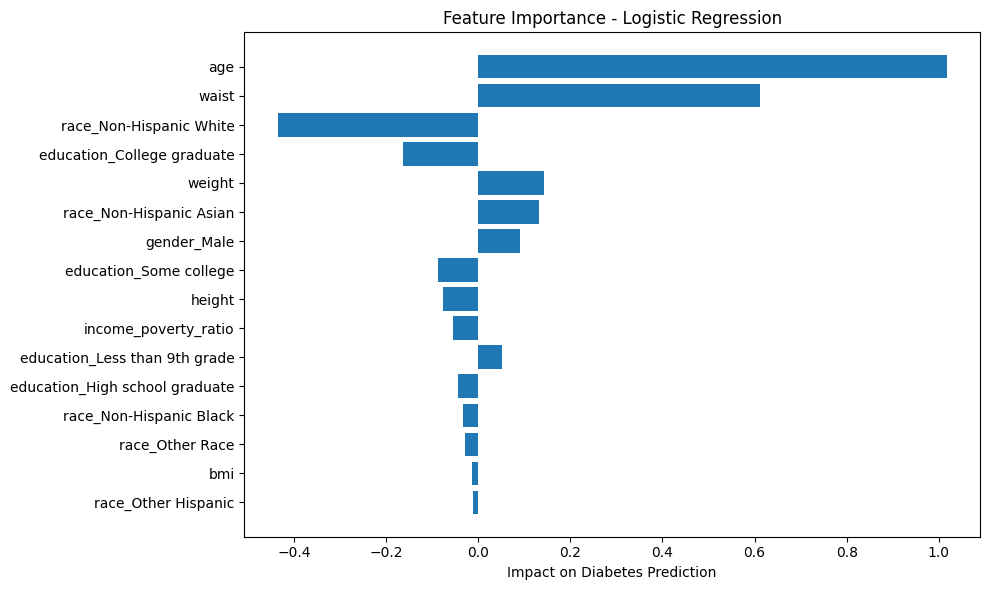

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importance from the balanced Logistic Regression
importance = lr_balanced.coef_[0]
features = X_train.columns

# Create a nice dataframe
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', key=abs, ascending=False)

print(importance_df)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Impact on Diabetes Prediction")
plt.title("Feature Importance - Logistic Regression")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
from xgboost import XGBClassifier

# Train XGBoost with balanced class weight
xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum(),  # handles imbalance
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost Results ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC Score: {:.3f}".format(roc_auc_score(y_test, y_prob_xgb)))

=== XGBoost Results ===
              precision    recall  f1-score   support

         0.0       0.89      0.84      0.86      1383
         1.0       0.28      0.36      0.32       234

    accuracy                           0.77      1617
   macro avg       0.58      0.60      0.59      1617
weighted avg       0.80      0.77      0.79      1617

ROC-AUC Score: 0.728


In [20]:
import plotly.express as px
import plotly.graph_objects as go

# 1. Feature Importance Interactive Chart
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lr_balanced.coef_[0]
}).sort_values('Importance', key=abs, ascending=True)

fig1 = px.bar(
    importance_df,
    x='Importance',
    y='Feature',
    orientation='h',
    title='Feature Importance for Diabetes Prediction',
    color='Importance',
    color_continuous_scale='RdBu'
)
fig1.show()

# 2. BMI vs Waist colored by Diabetes
fig2 = px.scatter(
    df_adults,
    x='bmi',
    y='waist',
    color='diabetes',
    title='BMI vs Waist Circumference by Diabetes Status',
    labels={'diabetes': 'Has Diabetes'},
    hover_data=['age', 'gender']
)
fig2.show()